### Libraries

In [1]:
import re
import os
import numpy as np
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
from matplotlib.ticker import AutoMinorLocator
from astropy.constants import L_sun
from matplotlib import gridspec
import astropy.units as u
from math import pi
import gc
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from astropy.table import Column
from scipy.stats import bootstrap

from __future__ import annotations
import os
import json
from astropy.cosmology import FlatwCDM

import pymultinest
import corner
from getdist import plots, MCSamples
import scipy.optimize as op
from scipy import stats
from scipy.stats import norm
from astropy.time import Time
import matplotlib.dates as mdates

from venn import venn

In [2]:
def HyperLeda(filename):
    """
    Lee una tabla tipo NED/HyperLEDA ignorando comentarios y headers,
    devolviendo todas las columnas en un DataFrame de pandas.
    """

    # Leer el archivo ignorando líneas de comentario
    df = pd.read_csv(
        filename,
        comment="#",
        sep=",",
        engine="python"
    )

    # Limpiar nombres de columnas
    df.columns = [c.strip() for c in df.columns]

    #Convertir todo lo que se pueda a numérico
    #for col in df.columns:
        #df[col] = pd.to_numeric(df[col], errors="ignore")

    return df

def SIMBAD(filename):
    """
    Lee una tabla tipo NED/HyperLEDA ignorando comentarios y headers,
    devolviendo todas las columnas en un DataFrame de pandas.
    """

    # Leer el archivo ignorando líneas de comentario
    df = pd.read_csv(
        filename,
        comment="#",
        sep="|",
        engine="python"
    )

    # Limpiar nombres de columnas
    df.columns = [c.strip() for c in df.columns]

    #Convertir todo lo que se pueda a numérico
    #for col in df.columns:
        #df[col] = pd.to_numeric(df[col], errors="ignore")

    return df

def NED(filename):
    """
    Lee una tabla tipo NED/HyperLEDA ignorando comentarios y headers,
    devolviendo todas las columnas en un DataFrame de pandas.
    """

    # Leer el archivo ignorando líneas de comentario
    df = pd.read_csv(
        filename,
        comment="#",
        sep=",",
        engine="python"
    )

    # Limpiar nombres de columnas
    df.columns = [c.strip() for c in df.columns]

    #Convertir todo lo que se pueda a numérico
    #for col in df.columns:
        #df[col] = pd.to_numeric(df[col], errors="ignore")

    return df

def Prev_Fer(filename):
    """
    Lee una tabla tipo NED/HyperLEDA ignorando comentarios y headers,
    devolviendo todas las columnas en un DataFrame de pandas.
    """

    # Leer el archivo ignorando líneas de comentario
    df = pd.read_csv(
        filename,
        comment="#",
        sep=",",
        engine="python"
    )

    # Limpiar nombres de columnas
    df.columns = [c.strip() for c in df.columns]

    #Convertir todo lo que se pueda a numérico
    #for col in df.columns:
        #df[col] = pd.to_numeric(df[col], errors="ignore")

    return df

In [3]:
df_dist = NED("/home/holman/HIIGalaxies/Modulus/ref_NED/0.LMC.csv")

df_dist['Method'] = df_dist['Method'].str.strip()
df_dist['Reference'] = df_dist['Reference'].str.strip()
df_dist = df_dist[df_dist['Reference'].str[0:4].astype(int) >= 2000]


PLRC = np.unique(df_dist[(df_dist['Method']=='Cepheids')    &   (df_dist['err(m-M)'].notnull())]['Reference'])
TRGB = np.unique(df_dist[(df_dist['Method']=='TRGB')    &   (df_dist['err(m-M)'].notnull())]['Reference'])
RRLy = np.unique(df_dist[(df_dist['Method']=='RR Lyrae')    &   (df_dist['err(m-M)'].notnull())]['Reference'])

print(len(PLRC), len(TRGB), len(RRLy))

df_dist

57 8 36


,No.,(m-M),err(m-M),Distance,Method,Reference,Notes,SN Name,Redshift,H0,LMCModulus
0,7,17.75,0.18,0.0355,Cepheids,2013A&A...550A..70G,"HV 12717, 1, VK(W), Baade-Wesselink",NaN,NaN,NaN,NaN
1,8,17.77,0.13,0.0358,Cepheids,2013A&A...550A..70G,"HV 12202, 1, VK(W), Baade-Wesselink",NaN,NaN,NaN,NaN
2,9,17.89,0.07,0.0379,Cepheids,2013A&A...550A..70G,"HV 2369, 1, VK(W), Baade-Wesselink",NaN,NaN,NaN,NaN
3,10,17.93,0.13,0.0385,Cepheids,2013A&A...550A..70G,"HV 12197, 1, VK(W), Baade-Wesselink",NaN,NaN,NaN,NaN
4,11,17.96,0.12,0.0390,Cepheids,2013A&A...550A..70G,"HV 12815, 1, VK(W), Baade-Wesselink",NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
271,674,18.64,0.04,0.0535,RR Lyrae,2001A&A...371..579K,"NGC 1466, for IC 4499 m-M = 16.47",NaN,NaN,NaN,NaN
272,675,18.64,0.04,0.0535,RR Lyrae,2001PASP..113..335M,NaN,NaN,NaN,NaN,NaN
273,677,18.68,0.10,0.0545,RR Lyrae,2015ApJ...807..127M,"70, K, GAL PL Benedict et al. 2011",NaN,NaN,NaN,NaN
274,678,18.68,0.05,0.0545,RR Lyrae,2009A&A...502..505B,Field LMC-E12,NaN,NaN,NaN,NaN


In [4]:
home = '/home/holman/HIIGalaxies/Modulus/ref_NED'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = NED(f"/home/holman/HIIGalaxies/Modulus/ref_NED/{b}")
    df_dist['Method'] = df_dist['Method'].str.strip()
    df_dist['Reference'] = df_dist['Reference'].str.strip()
    df_dist = df_dist[df_dist['Reference'].str[0:4].astype(int) >= 2000]


    PLRC = np.unique(df_dist[(df_dist['Method']=='Cepheids')    ]['Reference']) #&   (df_dist['err(m-M)'].notnull())
    TRGB = np.unique(df_dist[(df_dist['Method']=='TRGB')    ]['Reference']) # &   (df_dist['err(m-M)'].notnull())
    RRLy = np.unique(df_dist[(df_dist['Method']=='RR Lyrae')    ]['Reference']) #&   (df_dist['err(m-M)'].notnull())

    print(len(PLRC),"	", len(TRGB),"	", len(RRLy))
    #print(b,"     ",len(PLRC),"	", len(TRGB),"	", len(RRLy),"\n")
    #b,"     ", ,"\n"


64 	 8 	 40
1 	 9 	 1
0 	 4 	 0
16 	 17 	 6
12 	 8 	 0
14 	 7 	 0
3 	 3 	 0
10 	 0 	 0
1 	 7 	 0
4 	 5 	 0
8 	 0 	 0
11 	 0 	 0
9 	 0 	 0
0 	 8 	 0
0 	 3 	 0
25 	 6 	 0
1 	 4 	 0
14 	 9 	 3
0 	 0 	 0
0 	 1 	 0
0 	 0 	 0
11 	 4 	 0
8 	 1 	 0
12 	 4 	 0
10 	 0 	 0
0 	 0 	 0
10 	 0 	 0
20 	 0 	 0
9 	 0 	 0
1 	 4 	 0
0 	 2 	 0
0 	 8 	 0
3 	 2 	 0


In [5]:
df_dist = HyperLeda(f"/home/holman/HIIGalaxies/Modulus/ref_HyperLeda/0.LMC.csv")
df_dist = df_dist[df_dist['bibcode'].str[0:4].astype(int) >= 2000]
df_dist['$link[method_method]'] = df_dist['$link[method_method]'].str.strip()
df_dist['bibcode'] = df_dist['bibcode'].str.strip()

PLRC = np.unique(df_dist[df_dist['$link[method_method]']=='Cepheids']['bibcode'])
TRGB = np.unique(df_dist[df_dist['$link[method_method]']=='TRGB']['bibcode'])
RRLy = np.unique(df_dist[df_dist['$link[method_method]']=='RRLyrae']['bibcode'])

#print(b,"     ",len(PLRC),"	", len(TRGB),"	", len(RRLy),"\n")

df_dist

,$objname,$j2000,modulus,e_modulus,flimit,fquality,distance,e_distance,flimit.1,fquality.1,modc,$link[method_method],$link[iref_iref],$link[bibref_bibcode],$link[calib_calib_bibcode],pgc,dataset,bibcode,calib_bibcode,calibsys
1,ESO056-115,J052334.6-694522,18.5070,0.003000,NaN,NaN,0.050281,0.000070,NaN,NaN,18.507000,Cepheids,52042,Musella+2016,Cepheids:Fiorentino+2007,17223,52042,2016MNRAS.457.3084M,2007A&A...476..863F,NaN
2,ESO056-115,J052334.6-694522,18.5500,0.060000,NaN,NaN,0.051286,0.001437,NaN,NaN,18.534862,Cepheids,51879,Fouque+2003,Cepheids:Fouque+2003,17223,51879,2003LNP...635...21F,2003LNP...635...21F,NaN
4,ESO056-115,J052334.6-694522,18.3700,0.000000,NaN,NaN,0.047206,0.000000,NaN,NaN,18.398429,Cepheids,51470,Paturel+2002,Cepheids:Lanoix+1999,17223,51470,2002A&A...389...19P,1999MNRAS.308..969L,NaN
5,ESO056-115,J052334.6-694522,18.3400,0.060000,NaN,NaN,0.046559,0.001304,NaN,NaN,18.340000,Cepheids,51540,An+2007,,17223,51540,2007ApJ...671.1640A,NaN,An+2007
6,ESO056-115,J052334.6-694522,18.4000,0.050000,NaN,NaN,0.047863,0.001115,NaN,NaN,18.400000,Cepheids,51538,Benedict+2007,,17223,51538,2007AJ....133.1810B,NaN,Benedict+2007
8,ESO056-115,J052334.6-694522,18.3900,0.050000,NaN,NaN,0.047643,0.001110,NaN,NaN,18.389999,Cepheids,51539,van Leeuwen+2007,,17223,51539,2007MNRAS.379..723V,NaN,vanLeuwen+2007
9,ESO056-115,J052334.6-694522,18.4500,0.050000,NaN,NaN,0.048978,0.001141,NaN,NaN,18.450001,Cepheids,51539,van Leeuwen+2007,,17223,51539,2007MNRAS.379..723V,NaN,vanLeuwen+2007
10,ESO056-115,J052334.6-694522,18.4700,0.030000,NaN,NaN,0.049431,0.000688,NaN,NaN,18.469999,Cepheids,51539,van Leeuwen+2007,,17223,51539,2007MNRAS.379..723V,NaN,vanLeuwen+2007
11,ESO056-115,J052334.6-694522,18.5200,0.030000,NaN,NaN,0.050582,0.000704,NaN,NaN,18.520000,Cepheids,51539,van Leeuwen+2007,,17223,51539,2007MNRAS.379..723V,NaN,vanLeuwen+2007
12,ESO056-115,J052334.6-694522,18.4100,0.160000,NaN,NaN,0.048084,0.003677,NaN,NaN,18.410000,Cepheids,51542,Macri+2006,,17223,51542,2006ApJ...652.1133M,NaN,NaN


In [6]:
home = '/home/holman/HIIGalaxies/Modulus/ref_HyperLeda'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = HyperLeda(f"/home/holman/HIIGalaxies/Modulus/ref_HyperLeda/{b}")
    df_dist = df_dist[df_dist['bibcode'].str[0:4].astype(int) >= 2000]
    df_dist['$link[method_method]'] = df_dist['$link[method_method]'].str.strip()
    df_dist['bibcode'] = df_dist['bibcode'].str.strip()

    PLRC = np.unique(df_dist[(df_dist['$link[method_method]']=='Cepheids')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())
    TRGB = np.unique(df_dist[(df_dist['$link[method_method]']=='TRGB')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())
    RRLy = np.unique(df_dist[(df_dist['$link[method_method]']=='RRLyrae')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())

    #print(b,"     ",len(PLRC),"	", len(TRGB),"	", len(RRLy),"\n")
    print(len(PLRC),"	", len(TRGB),"	", len(RRLy))


13 	 3 	 4
3 	 2 	 0
0 	 6 	 0
11 	 12 	 3
9 	 9 	 0
10 	 6 	 0
2 	 2 	 0
9 	 1 	 0
0 	 6 	 0
4 	 5 	 0
7 	 1 	 0
8 	 0 	 0
8 	 0 	 0
0 	 10 	 0
0 	 5 	 0
15 	 7 	 0
2 	 6 	 0
10 	 6 	 2
0 	 0 	 0
0 	 0 	 0
0 	 0 	 0
9 	 3 	 0
2 	 0 	 0
12 	 3 	 0
10 	 0 	 0
11 	 0 	 0
9 	 0 	 0
11 	 0 	 0
8 	 0 	 0
0 	 6 	 0
0 	 6 	 0
0 	 9 	 0
0 	 1 	 0


In [7]:
home = '/home/holman/HIIGalaxies/Modulus/ref_SIMBAD'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = SIMBAD(f"/home/holman/HIIGalaxies/Modulus/ref_SIMBAD/{b}")
    df_dist = df_dist[df_dist['reference'].str[0:4].astype(int) >= 2000]
    #print(df_dist)
    df_dist['reference'] = df_dist['reference'].str.strip()
    df_dist['method'] = df_dist['method'].str.strip()
    df_dist['err-        err+'] = df_dist['err-        err+'].str.strip()

    PLRC = np.unique(df_dist[(df_dist['method'].str[0:3] == 'Cep')]['reference'])
    TRGB = np.unique(df_dist[((df_dist['method'] == 'T-RGB') | (df_dist['method'] == 'TRGB') )]['reference'])
    RRLy = np.unique(df_dist[(df_dist['method'].str[0:3] == 'RR') ]['reference'])
    NoID = np.unique(df_dist[(df_dist['method'] == '')]['reference'])


    print(len(PLRC),"	", len(TRGB),"	", len(RRLy),"	", len(NoID))
    #b,"     ", ,"\n"

#print(PLRC,TRGB,RRLy)
#print(len(PLRC),"	", len(TRGB),"	", len(RRLy),"	", len(NoID))
#print('+' in df_dist.iloc[6].str[0:20]['err-        err+'])
#df_dist

2 	 0 	 0 	 3
1 	 1 	 0 	 2
0 	 4 	 0 	 3
3 	 1 	 0 	 3
3 	 0 	 0 	 3
2 	 0 	 0 	 5
0 	 0 	 0 	 2
3 	 0 	 0 	 5
1 	 1 	 0 	 3
3 	 1 	 0 	 5
2 	 0 	 0 	 5
5 	 0 	 0 	 4
2 	 0 	 0 	 5
0 	 1 	 0 	 3
0 	 2 	 0 	 5
2 	 0 	 0 	 5
0 	 3 	 0 	 4
3 	 0 	 0 	 4
0 	 0 	 0 	 1
0 	 0 	 0 	 3
0 	 0 	 0 	 3
3 	 0 	 0 	 3
1 	 0 	 0 	 3
3 	 0 	 0 	 4
2 	 0 	 0 	 6
2 	 0 	 0 	 3
2 	 0 	 0 	 3
3 	 0 	 0 	 3
3 	 0 	 0 	 3
1 	 1 	 0 	 3
0 	 3 	 0 	 2
0 	 2 	 0 	 3
0 	 0 	 0 	 2


In [8]:
home = '/home/holman/HIIGalaxies/Modulus/TABLES'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

PLRC_list = [x for x in list_files if 'PLRC' in x]

for b in PLRC_list:
    df_dist = Prev_Fer(f"/home/holman/HIIGalaxies/Modulus/TABLES/{b}")
    PLRC = np.unique(df_dist['RefCode'])

    print(b,"     ",len(PLRC))

1.IC0010_PLRC.csv       1
3.M33_PLRC.csv       11
4.M81_PLRC.csv       10
5.M101_PLRC.csv       10
6.MRK116_PLRC.csv       1
7.NGC0925_PLRC.csv       7
9.NGC2403_PLRC.csv       2
10.NGC2541_PLRC.csv       5
11.NGC3198_PLRC.csv       6
12.NGC3319_PLRC.csv       6
15.NGC4258_PLRC.csv       18
16.NGC4395_PLRC.csv       1
17.NGC6822_PLRC.csv       12


In [9]:
home = '/home/holman/HIIGalaxies/Modulus/TABLES'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

TRGB_list = [x for x in list_files if 'TRGB' in x]

for b in TRGB_list:
    df_dist = Prev_Fer(f"/home/holman/HIIGalaxies/Modulus/TABLES/{b}")
    TRGB = np.unique(df_dist['RefCode'])

    print(b[0:2],"     ",len(TRGB))


1.       5
2.       3
3.       14
4.       6
5.       7
6.       1
8.       5
9.       5
13       7
14       3
15       6
16       3
17       4


### Meter todo en un txt y luego hacer diagramas de Venn

In [10]:
home = '/home/holman/HIIGalaxies/Modulus/ref_NED'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = NED(f"/home/holman/HIIGalaxies/Modulus/ref_NED/{b}")
    df_dist['Method'] = df_dist['Method'].str.strip()
    df_dist['Reference'] = df_dist['Reference'].str.strip()
    df_dist = df_dist[df_dist['Reference'].str[0:4].astype(int) >= 2000]
    PLRC = np.unique(df_dist[(df_dist['Method']=='Cepheids')    ]['Reference']) #&   (df_dist['err(m-M)'].notnull())
    TRGB = np.unique(df_dist[(df_dist['Method']=='TRGB')    ]['Reference']) # &   (df_dist['err(m-M)'].notnull())
    RRLy = np.unique(df_dist[(df_dist['Method']=='RR Lyrae')    ]['Reference']) #&   (df_dist['err(m-M)'].notnull())

    Gal_name = b.replace('.csv','')

    PLRC_toTXT,TRGB_toTXT,RRLy_toTXT = [['NED',Gal_name,x,'Cepheids'] for x in PLRC],[['NED',Gal_name,x,'TRGB'] for x in TRGB],[['NED',Gal_name,x,'RRLyrae'] for x in RRLy]

    with open("/home/holman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt", "a+") as f:
        for i in range(len(PLRC_toTXT)):
            f.write(f"{PLRC_toTXT[i][0]},{PLRC_toTXT[i][1]},{PLRC_toTXT[i][2]},{PLRC_toTXT[i][3]}\n")
        for i in range(len(TRGB_toTXT)):
            f.write(f"{TRGB_toTXT[i][0]},{TRGB_toTXT[i][1]},{TRGB_toTXT[i][2]},{TRGB_toTXT[i][3]}\n")
        for i in range(len(RRLy_toTXT)):
            f.write(f"{RRLy_toTXT[i][0]},{RRLy_toTXT[i][1]},{RRLy_toTXT[i][2]},{RRLy_toTXT[i][3]}\n")


In [11]:
home = '/home/holman/HIIGalaxies/Modulus/ref_HyperLeda'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = HyperLeda(f"/home/holman/HIIGalaxies/Modulus/ref_HyperLeda/{b}")
    df_dist = df_dist[df_dist['bibcode'].str[0:4].astype(int) >= 2000]
    df_dist['$link[method_method]'] = df_dist['$link[method_method]'].str.strip()
    df_dist['bibcode'] = df_dist['bibcode'].str.strip()

    PLRC = np.unique(df_dist[(df_dist['$link[method_method]']=='Cepheids')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())
    TRGB = np.unique(df_dist[(df_dist['$link[method_method]']=='TRGB')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())
    RRLy = np.unique(df_dist[(df_dist['$link[method_method]']=='RRLyrae')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())

    Gal_name = b.replace('.csv','')

    PLRC_toTXT,TRGB_toTXT,RRLy_toTXT = [['HyperLeda',Gal_name,x,'Cepheids'] for x in PLRC],[['HyperLeda',Gal_name,x,'TRGB'] for x in TRGB],[['HyperLeda',Gal_name,x,'RRLyrae'] for x in RRLy]

    with open("/home/holman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt", "a+") as f:
        for i in range(len(PLRC_toTXT)):
            f.write(f"{PLRC_toTXT[i][0]},{PLRC_toTXT[i][1]},{PLRC_toTXT[i][2]},{PLRC_toTXT[i][3]}\n")
        for i in range(len(TRGB_toTXT)):
            f.write(f"{TRGB_toTXT[i][0]},{TRGB_toTXT[i][1]},{TRGB_toTXT[i][2]},{TRGB_toTXT[i][3]}\n")
        for i in range(len(RRLy_toTXT)):
            f.write(f"{RRLy_toTXT[i][0]},{RRLy_toTXT[i][1]},{RRLy_toTXT[i][2]},{RRLy_toTXT[i][3]}\n")

In [12]:
home = '/home/holman/HIIGalaxies/Modulus/ref_SIMBAD'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = SIMBAD(f"/home/holman/HIIGalaxies/Modulus/ref_SIMBAD/{b}")
    df_dist = df_dist[df_dist['reference'].str[0:4].astype(int) >= 2000]
    #print(df_dist)
    df_dist['reference'] = df_dist['reference'].str.strip()
    df_dist['method'] = df_dist['method'].str.strip()
    df_dist['err-        err+'] = df_dist['err-        err+'].str.strip()

    PLRC = np.unique(df_dist[(df_dist['method'].str[0:3] == 'Cep')]['reference'])
    TRGB = np.unique(df_dist[((df_dist['method'] == 'T-RGB') | (df_dist['method'] == 'TRGB') )]['reference'])
    RRLy = np.unique(df_dist[(df_dist['method'].str[0:3] == 'RR') ]['reference'])
    NoID = np.unique(df_dist[(df_dist['method'] == '')]['reference'])

    Gal_name = b.replace('.csv','')

    PLRC_toTXT,TRGB_toTXT,RRLy_toTXT = [['SIMBAD',Gal_name,x,'Cepheids'] for x in PLRC],[['SIMBAD',Gal_name,x,'TRGB'] for x in TRGB],[['SIMBAD',Gal_name,x,'RRLyrae'] for x in RRLy]

    NoID_toTXT = [['SIMBAD',Gal_name,x,'NoID'] for x in NoID]


    with open("/home/holman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt", "a+") as f:
        for i in range(len(PLRC_toTXT)):
            f.write(f"{PLRC_toTXT[i][0]},{PLRC_toTXT[i][1]},{PLRC_toTXT[i][2]},{PLRC_toTXT[i][3]}\n")
        for i in range(len(TRGB_toTXT)):
            f.write(f"{TRGB_toTXT[i][0]},{TRGB_toTXT[i][1]},{TRGB_toTXT[i][2]},{TRGB_toTXT[i][3]}\n")
        for i in range(len(RRLy_toTXT)):
            f.write(f"{RRLy_toTXT[i][0]},{RRLy_toTXT[i][1]},{RRLy_toTXT[i][2]},{RRLy_toTXT[i][3]}\n")
        for i in range(len(NoID_toTXT)):
            f.write(f"{NoID_toTXT[i][0]},{NoID_toTXT[i][1]},{NoID_toTXT[i][2]},{NoID_toTXT[i][3]}\n")

In [13]:
home = '/home/holman/HIIGalaxies/Modulus/TABLES'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

PLRC_list = [x for x in list_files if 'PLRC' in x]

for b in PLRC_list:
    Gal_name = b.replace('.csv','')
    Gal_name = Gal_name.replace('_PLRC','')
    df_dist = Prev_Fer(f"/home/holman/HIIGalaxies/Modulus/TABLES/{b}")
    PLRC = np.unique(df_dist['RefCode'])
    PLRC_toTXT = [['Fernando',Gal_name,x,'Cepheids'] for x in PLRC]
    with open("/home/holman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt", "a+") as f:
        for i in range(len(PLRC_toTXT)):
            f.write(f"{PLRC_toTXT[i][0]},{PLRC_toTXT[i][1]},{PLRC_toTXT[i][2]},{PLRC_toTXT[i][3]}\n")


TRGB_list = [x for x in list_files if 'TRGB' in x]

for b in TRGB_list:
    Gal_name = b.replace('.csv','')
    Gal_name = Gal_name.replace('_TRGB','')
    df_dist = Prev_Fer(f"/home/holman/HIIGalaxies/Modulus/TABLES/{b}")
    TRGB = np.unique(df_dist['RefCode'])
    TRGB_toTXT = [['Fernando',Gal_name,x,'TRGB'] for x in TRGB]
    with open("/home/holman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt", "a+") as f:
        for i in range(len(TRGB_toTXT)):
            f.write(f"{TRGB_toTXT[i][0]},{TRGB_toTXT[i][1]},{TRGB_toTXT[i][2]},{TRGB_toTXT[i][3]}\n")


In [14]:
df_Venn = pd.read_csv("/home/holman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt",
                       sep=',',
                        names=['Source', 'Galaxy', 'Ref','Method'])
df_Venn

,Source,Galaxy,Ref,Method
0,NED,0.LMC,2000A&A...356..849G,Cepheids
1,NED,0.LMC,2000A&A...363..901G,Cepheids
2,NED,0.LMC,2000ApJ...529..745F,Cepheids
3,NED,0.LMC,2000ApJ...533..215C,Cepheids
4,NED,0.LMC,2000ApJ...533L.107G,Cepheids
...,...,...,...,...
1098,Fernando,16.NGC4395,2018ApJS..235...23S,TRGB
1099,Fernando,17.NGC6822,2000ApJ...529..745F,TRGB
1100,Fernando,17.NGC6822,2005A&A...429..837C,TRGB
1101,Fernando,17.NGC6822,2011AJ....141..194G,TRGB


In [36]:
##Galaxia 

NAME = '1.IC0010'
METHOD = 'TRGB'

NED_v = df_Venn[(df_Venn['Source']=='NED') & (df_Venn['Galaxy']==NAME) & (df_Venn['Method']==METHOD) ]['Ref'].tolist()
HyperLeda_v = df_Venn[(df_Venn['Source']=='HyperLeda') & (df_Venn['Galaxy']==NAME) & (df_Venn['Method']==METHOD) ]['Ref'].tolist()
SIMBAD_v = df_Venn[(df_Venn['Source']=='SIMBAD') & (df_Venn['Galaxy']==NAME) & (df_Venn['Method']==METHOD) ]['Ref'].tolist()
Fernando_v = df_Venn[(df_Venn['Source']=='Fernando') & (df_Venn['Galaxy']==NAME) & (df_Venn['Method']==METHOD) ]['Ref'].tolist()


In [37]:
Fernando_v

['2000ApJ...529..745F',
 '2007ApJ...662..272V',
 '2008ApJ...688L..69S',
 '2009ApJ...703..816K',
 '2017ApJ...834...78M']

In [38]:
Claves = ['NED','HyperLeda','SIMBAD','Fernando']
Sets = [set(NED_v), set(HyperLeda_v), set(SIMBAD_v), set(Fernando_v)]

Diccionario = dict(zip(Claves, Sets))

<Axes: >

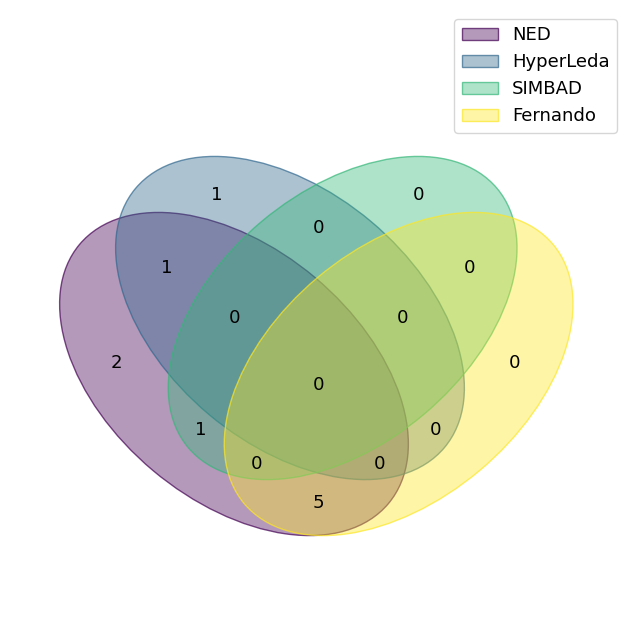

In [39]:
Galaxy = Diccionario
venn(Galaxy)